<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 8</b></center>    
<pre>    

# import necessary libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings

<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

# Import diabetes.csv data ser using sklearn

In [2]:
df  = pd.read_csv('diabetes.csv')

In [5]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB


# Check the distribution of the target

In [8]:
print(df['Outcome'].value_counts())

Outcome
Non Diabetic    500
Diabetic        268
Name: count, dtype: int64


# Replace zeros with NaN for specific columns

In [9]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction']

df[cols] = df[cols].replace(0, np.nan)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,Diabetic
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,Non Diabetic
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,Diabetic
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,Non Diabetic
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,Diabetic


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Check for missing values

In [11]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Fill missing values with median

In [15]:
# for col in cols:
#     df[col].fillna(df[col].median(), inplace=True)

for col in cols:
    df[col] = df[col].fillna(df[col].median())


In [16]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Visualize Distributions

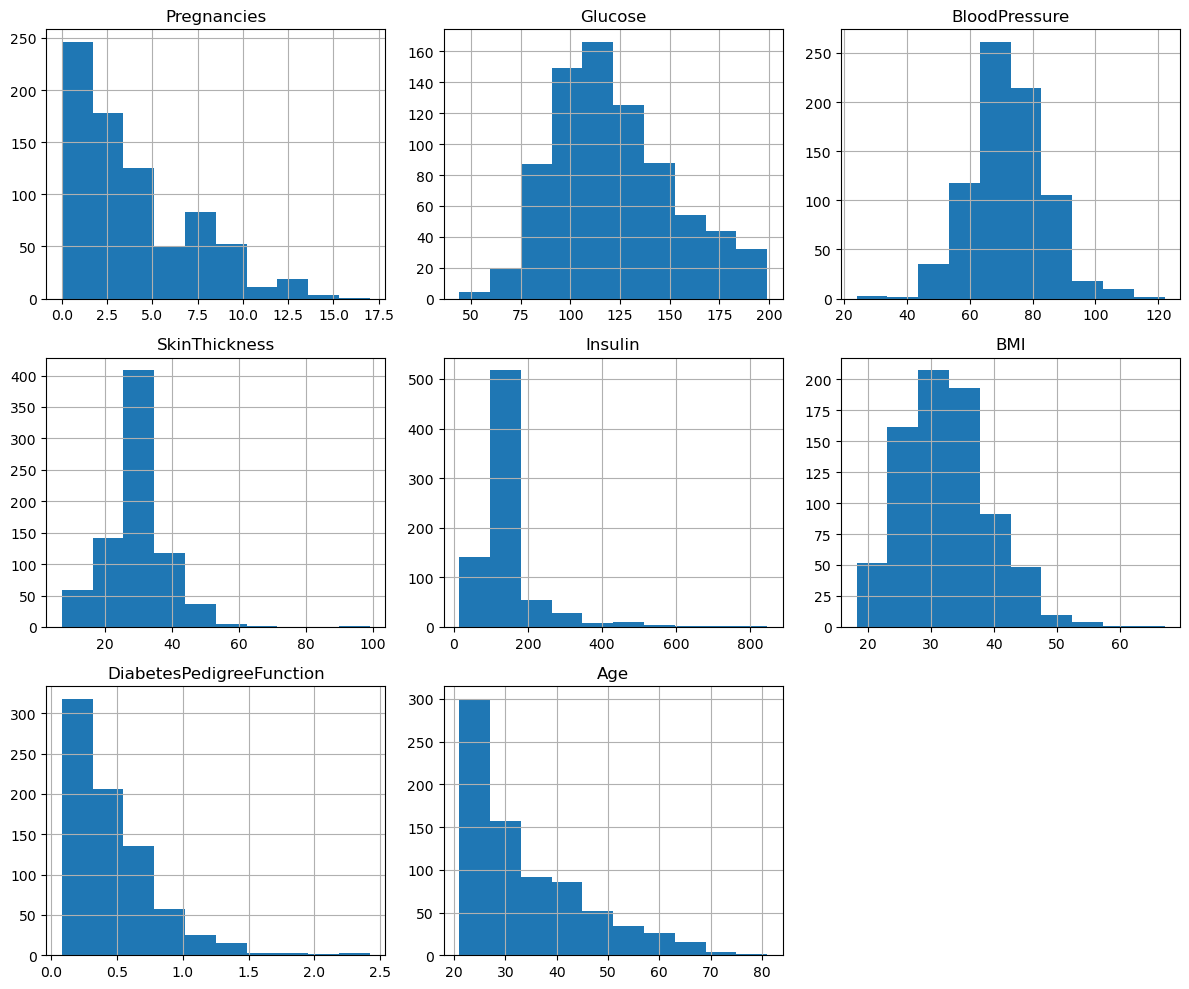

In [18]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

<AxesSubplot:>

# Convert Targer data into interger code

In [19]:
df['Outcome'].unique()

array(['Diabetic', 'Non Diabetic'], dtype=object)

In [20]:
le = LabelEncoder()
df['Outcome'] = le.fit_transform(df['Outcome'])

# Divide the data into input and output

In [21]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(X.shape)
print(y.shape)

(768, 8)
(768,)


# Splitting the dataset into the Training set and Test set

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape

(614, 8)

# Create Model

In [31]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [32]:
model = DecisionTreeClassifier(max_depth=2, random_state=42)

In [33]:
# for depth in range(1,11):
#     model = DecisionTreeClassifier(
#         max_depth = depth,
#         random_state=42
#     )

model.fit(X_train,y_train)

print()

# Fitting DecisionTreeClassifier   on dataset

In [34]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

# Display Decision Tree

In [35]:
plt.figure(figsize=(20,10))

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<function matplotlib.pyplot.show(close=None, block=None)>

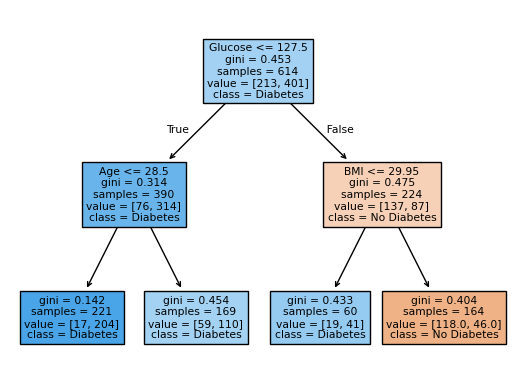

In [37]:
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No Diabetes','Diabetes'],
    filled=True
)
plt.show

# Predict the x_test 

In [38]:
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 0 0 0 1 0 0
 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 1 1
 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 0 1 1 1
 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 1 1 1
 1 0 1 1 1 1]


# Display Training Accuracy

In [41]:
train_pred = model.predict(X_train)

train_acc = accuracy_score(y_train,train_pred)

print("Training Accuracy: ",train_acc)

Training Accuracy:  0.7703583061889251


# Display Test Accuracy

In [42]:
test_acc = accuracy_score(y_test,y_pred)

print("testing accuracy ",test_acc)

testing accuracy  0.7727272727272727
